In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
%matplotlib inline

In [3]:
stocks = input("Enter the code of the stock: ")
data = yf.download(stocks, "2020-01-01","2026-01-01", auto_adjust = True)
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,USD,USD,USD,USD,USD
Date,,,,,
2020-01-02,3.953887,3.953887,3.868188,3.903948,849600
2020-01-03,3.827496,3.878669,3.792970,3.851541,907200
2020-01-06,3.766458,3.778789,3.699255,3.734398,843200
2020-01-07,3.857091,3.894083,3.791737,3.823797,758400
2020-01-08,3.853391,3.894083,3.823180,3.858940,499200


In [4]:
data.shape

(1508, 5)

In [5]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1508 entries, 2020-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, USD)   1508 non-null   float64
 1   (High, USD)    1508 non-null   float64
 2   (Low, USD)     1508 non-null   float64
 3   (Open, USD)    1508 non-null   float64
 4   (Volume, USD)  1508 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 70.7 KB


In [6]:
data.describe().T

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Close,USD,1508.0,1.551873e+01,13.790049,1.744199,5.781078,9.172020,2.394782e+01,6.333145e+01
High,USD,1508.0,1.590952e+01,14.122707,1.945192,5.943573,9.387221,2.453852e+01,6.471776e+01
Low,USD,1508.0,1.509167e+01,13.432839,1.579582,5.650444,8.966711,2.295962e+01,6.145644e+01
Open,USD,1508.0,1.553788e+01,13.832728,1.755296,5.800761,9.160888,2.382348e+01,6.278790e+01
Volume,USD,1508.0,1.058113e+06,830789.325216,144800.000000,532700.000000,849600.000000,1.315900e+06,9.537600e+06


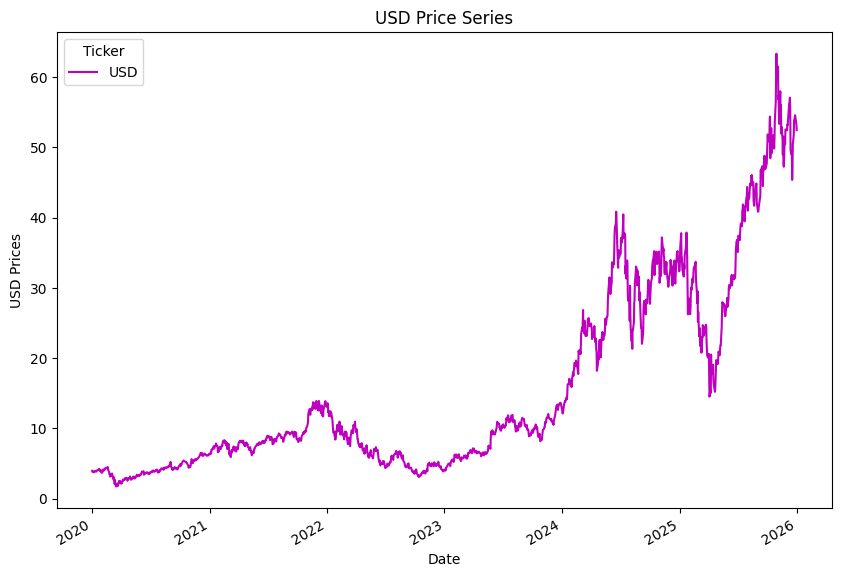

<Figure size 640x480 with 0 Axes>

In [7]:
data.Close.plot(figsize = (10, 7), color='m' )
plt.ylabel("{} Prices".format(stocks))
plt.title("{} Price Series".format(stocks))
plt.show()
plt.savefig("plot1.png")

In [8]:
data.isnull().sum()

Price   Ticker
Close   USD       0
High    USD       0
Low     USD       0
Open    USD       0
Volume  USD       0
dtype: int64

<Axes: ylabel='Density'>

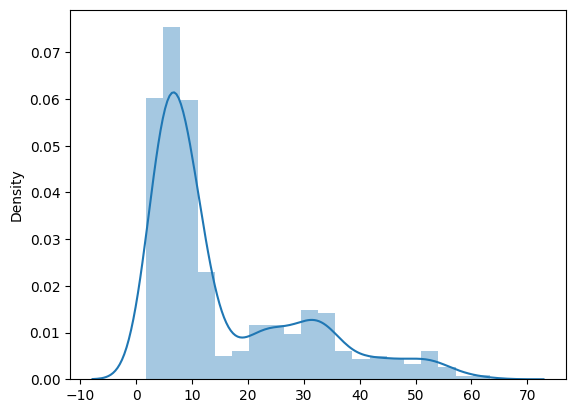

In [9]:
sns.distplot(data['Close'])

<Axes: ylabel='Density'>

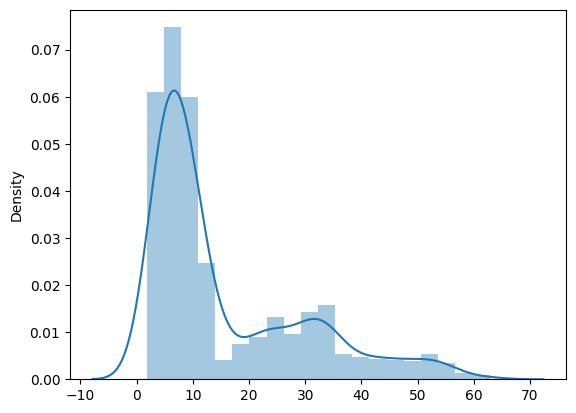

In [10]:
sns.distplot(data['Open'])

<Axes: ylabel='Density'>

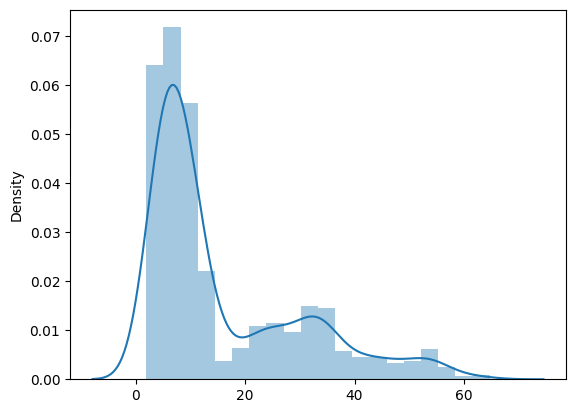

In [11]:
sns.distplot(data['High'])

In [12]:
X = data.drop("Close", axis = 1)
y = data.Close

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1206, 4)
(302, 4)
(1206, 1)
(302, 1)


In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
pred1 = linear_model.predict(X_test)

In [16]:
predictions = pd.DataFrame(pred1)
predictions.head()

,0
0,7.772455
1,29.902875
2,8.487649
3,6.602462
4,9.306601


In [17]:
y_test.head(5)

Ticker,USD
Date,
2022-04-19,7.898128
2024-07-24,29.274673
2021-07-09,8.580834
2022-04-26,6.475821
2023-11-02,9.307758


In [18]:
from sklearn.metrics import r2_score, mean_squared_error
def calculate_metrics(y_test, pred1):
    """
    y_test = ground truth/ actual value
    y_pred = model predictions
    """
    mse = mean_squared_error(y_test, pred1)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred1)
    
    print("Mean Squared Error = ", mse)
    print("RMSE = ", rmse)
    print("R2_score = ", r2)

calculate_metrics(y_test, pred1)

Mean Squared Error =  0.08591487956488851
RMSE =  0.2931124009060151
R2_score =  0.9996085966417905


In [19]:
from sklearn.linear_model import Lasso, Ridge

lasso_model = Lasso().fit(X_train, y_train)
ridge_model= Ridge().fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)
ridge_pred = ridge_model.predict(X_test)

In [20]:
calculate_metrics(y_test, lasso_pred)

Mean Squared Error =  0.24595676957500462
RMSE =  0.4959402883160478
R2_score =  0.9988794920498805


In [21]:
calculate_metrics(y_test, ridge_pred)

Mean Squared Error =  0.08624354171716724
RMSE =  0.2936725075950543
R2_score =  0.9996070993520222


In [22]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

svr = SVR()

params = {"C": [0.1, 1, 10, 100, 1000],
         "gamma": [1, 0.1, 0.01, 0.001, 0.0001],
          "kernel": ['rbf']
         }
grid = GridSearchCV(SVR(), params, refit = True, verbose = 3)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.285 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.111 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.176 total time=   0.0s
[CV 4/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.236 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.262 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.1, kernel=rbf;, score=-0.284 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.1, kernel=rbf;, score=-0.111 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=0.1, kernel=rbf;, score=-0.175 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=0.1, kernel=rbf;, score=-0.236 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=0.1, kernel=rbf;, score=-0.262 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=0.01, kernel=rbf;, score=-0.283 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=0.01, kernel=rbf;

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and c

In [23]:
svr = SVR(C = 1000, gamma = 0.0001, kernel = 'rbf')
svr.fit(X_train, y_train)
svr_pred = svr.predict(X_test)
df = pd.DataFrame(svr_pred)

In [24]:
import joblib
joblib.dump(linear_model, 'linear_model.pkl')

['linear_model.pkl']

In [25]:
def predict_price(Open, High, Low, Volume):
    test_data = np.array([[Open, High, Low, Volume]])
    trained_model = joblib.load("linear_model.pkl")
    prediction = trained_model.predict(test_data)
    return prediction
    
predict_price(100,220,3400,30000)

array([[-1815.59917701]])